## Academic Domain Classification of UC Library Research Guides

### LIN 127 Final Project

I work at the UC Davis DataLab, where I've been building a RAG-based virtual librarian
chatbot that synthesizes UC Davis Library research guides. Having already scraped, cleaned, and
chunked the corpus for retrieval purposes, it seemed like a natural opportunity to ask a
more linguistic question: does the text of these chunks carry enough signal to identify
the academic domain it came from - without relying on the guide's title or URL?

This notebook explores that question through feature extraction and Naive Bayes classification.

The corpus consists of ~7,400 text chunks. Each chunk belongs to a specific guide (e.g. *Sociology*, *Agriculture & Related Fields*, *ANS 134: Animal Nutrition Laboratory*), and guides are grouped into four broad academic domains:

| Domain | Examples |
|---|---|
| STEM | Biology, Chemistry, Agriculture, Animal Science, Nutrition |
| Humanities | Literature, History, Art, African American Studies, Film |
| Social Sciences | Sociology, Psychology, Political Science, Economics |
| Health Sciences | Nursing, Medicine, Veterinary, Public Health, Kinesiology |
| Other | Business, Management, UWP, Postdoctoral Programs|

---

***Do research guides across these domains exhibit measurably different linguistic profiles in how they describe databases, resources, and research tools?***

**Method:** Rule-based domain labeling from guide titles -> NLTK bag-of-words feature extraction -> Naive Bayes classification → Most Informative Features analysis.


### 1. Setup

In [1]:
import pandas as pd
import numpy as np
import re
import random
import warnings
from collections import Counter
warnings.filterwarnings('ignore')

import nltk
import ssl
from nltk.classify import NaiveBayesClassifier
from nltk.classify.util import accuracy as nltk_accuracy
from nltk.corpus import stopwords

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Fix SSL certificate issue (was stuck on this for a very long time)
ssl._create_default_https_context = ssl._create_unverified_context

NLTK_DIR = '../../../../data/nltk_data' # specified directory 

# NLTK data, like in assignment 6
nltk.download('punkt',                          download_dir=NLTK_DIR) # word tokenizer model
nltk.download('punkt_tab',                      download_dir=NLTK_DIR) # word tokenizer model
nltk.download('averaged_perceptron_tagger',     download_dir=NLTK_DIR) # part-of-speech tagger
nltk.download('averaged_perceptron_tagger_eng', download_dir=NLTK_DIR) # part-of-speech tagger
nltk.download('stopwords',                      download_dir=NLTK_DIR) # stop words list to help filtering out common words


# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ── Configuration ──────────────────────────────────────────────────────────────
DATA_PATH    = '../../../../data/combined_text_full_libguide.csv'   # purposefully vague for path anonimity 
TEST_SPLIT   = 0.20                         # 80/20 train/test split
TOP_WORDS    = 2000                         # vocabulary size for bag of words features

[nltk_data] Downloading package punkt to ../../../../data/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     ../../../../data/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ../../../../data/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     ../../../../data/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     ../../../../data/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### 2. Data Loading
Loading my corpus (CSV) and displaying the shape/structure for readers.

In [2]:
df = pd.read_csv(DATA_PATH) # I'm used to using df as dataframe because I've worked a bit in R

print(f"Total chunks: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"Unique guides (parent_id): {df['parent_id'].nunique():,}")
print(f"Unique libguide_titles: {df['libguide_title'].nunique():,}")
print()
df.head(3)


Total chunks: 7,442
Columns: ['local_id', 'parent_id', 'text', 'libguide_title', 'libguide_url', 'chunk_title', 'chunk_url', 'external_url', 'combined_text']
Unique guides (parent_id): 1,040
Unique libguide_titles: 159



,local_id,parent_id,text,libguide_title,libguide_url,chunk_title,chunk_url,external_url,combined_text
0,1,2,Black Studies Center brings together historica...,African and African American Studies,https://guides.library.ucdavis.edu/african-and...,Black Studies Center,NaN,https://www.proquest.com/bsc,Guide Title: African and African American Stud...
1,2,2,IIBP Full Text includes current and retrospect...,African and African American Studies,https://guides.library.ucdavis.edu/african-and...,Black Studies Periodicals Database,NaN,https://www.proquest.com/bpd/advanced,Guide Title: African and African American Stud...
2,3,2,In February 2008 this English-language databas...,African and African American Studies,https://guides.library.ucdavis.edu/african-and...,Africana Periodical Literature Bibliographic D...,NaN,https://www.africabib.org/perio.php,Guide Title: African and African American Stud...


### 3a. Domain Labeling

Because I'll be working with a classifier (a supervized machine learning model), I know the model will need labels, however I realized that instead of manually annotating thousands of chunks, I can use the `libguide_title` fields instead. A keyword-based rule assigns each guide to one of four academic domains.

The labels don't come from the text itself, which means the classification task is a genuine test of whether the text *independently* reflects domain membership.

I also realized I should strip the titles of the course-code prefixes (e.g. `ANS 134:`, `NUT 117:`) so that keyword matching operates on the meaningful part of the titles.

---

### NOTE:
In the first round of doing this, ~1653 chunks ended up Unclassified because my keyword lists weren't specific enough and missing a bunch of sub-categories. So what I did was, extract just the titles of those Unclassified ones and write them to a CSV file:

`
df[df['domain'] == 'Unclassified']['libguide_title'].to_csv('unclassified_titles.txt', index=False, header=False)
`

Then I gave this to Claude to get additional suggest keyword mapings, and I added those at the end of the lists I already had made. This allowed me to narrow down every single title, so there are currently 0 Unclassified ones.

In [3]:
import nltk
nltk.data.path.insert(0, '/dsl/libbot/data/nltk_data')


def clean_title(title):
    """
    Remove leading course-code prefixes like 'ANS 134: ' or 'NUT 117B: '.
    
    Parameters
    ----------
    title: str
        The title of a library guide

    Returns
    -------
    str
        Cleaned version of the title
    """
    return re.sub(r'^[A-Z]{2,4}\s*\d+[A-Z]?\s*:\s*', '', str(title)).strip()


def assign_domain(title):
    """
    Map a libguide_title to one of four broad academic domains using keyword matching.
    
    Parameters
    ----------
    title: str
        The cleaned title of a library guide

    Returns
    -------
    str
        One of four academic domains (classes)
        'Unclassified' if no keywords match

    
    """
    # keeping both to eventually match against both the original and cleaned titles
    original = title.strip().lower()
    t = clean_title(title).lower()


    # I had AI help in generating these keywords for the categories
    health_kw = [
        'nursing', 'medicine', 'medical', 'pharmacy', 'health', 'clinical',
        'veterinary', 'physician', 'dental', 'epidemiology', 'kinesiology',
        'exercise biology', 'rehabilitation', 'occupational therapy',
        'physical therapy', 'public health', 'physician assistant',
        'laboratory animal', 'family stress', 'resilience', 'vet'
    ]

    stem_kw = [
        'biology', 'biochem', 'chemistry', 'physics', 'mathematics', 'math',
        'statistic', 'engineering', 'computer science', 'agriculture',
        'animal science', 'animal nutrition', 'animal biology',
        'nutrition', 'environmental', 'ecology', 'geology', 'neuroscience',
        'molecular', 'entomology', 'botany', 'plant', 'soil science',
        'food science', 'viticulture', 'enology', 'atmospheric',
        'genomics', 'bioinformatics', 'toxicology', 'microbiology',
        'biological', 'chemical', 'natural resource', 'wildlife',
        'fisheries', 'hydrology', 'climate', 'data science', 'science',
        'avian', 'semiconductor', 'manufacturing', 'energy', 'transportation',
        'wild davis', 'reptile', 'poultry', 'birds',
        'ans ', 'eme ', 'eec ', 'eve ', 'fys ',
        'ans 1', 'eme 0', 'eec 2', 'eve 1',
        'pls-007', 'just coffee',
    ]
    
    humanities_kw = [
        'literature', 'history', 'art history', 'studio art', 'music',
        'philosophy', 'film', 'theater', 'theatre', 'language studies',
        'african american', 'african and african', 'asian american',
        'chicano', 'chicana', 'ethnic studies', 'gender studies', "women's studies",
        'culture', 'classics', 'classical studies', 'medieval', 'religious studies',
        'religion', 'archaeology', 'linguistics', 'writing', 'rhetoric', 'poetry',
        'drama', 'creative writing', 'american studies', 'humanities',
        'visual art', 'performance', 'design history',
        'fashion', 'costume', 'landscape architecture', 'designed geographies',
        'video games', 'arboretum', 'bhakti', 'rst ',
    ]
    
    social_kw = [
        'sociology', 'psychology', 'political science', 'economics',
        'anthropology', 'communication', 'education', 'geography',
        'law', 'legal studies', 'criminology', 'social work',
        'public policy', 'international relations', 'human development',
        'cognitive science', 'labor studies', 'urban studies',
        'global studies', 'international', 'community development',
        'african diaspora', 'disability studies', 'middle eastern', 'south asian',
        'interpersonal', 'social media', 'families', 'family stress',
        'artificial intelligence in society', 'sts 1',
        'cmn ', 'hde ', 'esp ', 'des 40',
    ]
    
    other_kw = [
        'business', 'marketing', 'management',
        'mcnair', 'honors program', 'university honors',
        'postdoctoral', 'psa:',
        'uwp', 'academic literacies', 'uwp1',
        'cooperative extension', 'anr',
        'leaddr', 'avenuee',
        'mgt ', 'mgb ', 'pls-',
    ]

    # Check in specificity order (health before STEM to avoid overlap; figured this out the hard way)
    # This tries the original lowercased title first (catching things like esp, uwp, vet),
    # and if nothing matches it tries the cleaned version. 
    for check in [original, t]:
        for kw in health_kw:
            if kw in check:
                return 'Health Sciences'
        for kw in stem_kw:
            if kw in check:
                return 'STEM'
        for kw in humanities_kw:
            if kw in check:
                return 'Humanities'
        for kw in social_kw:
            if kw in check:
                return 'Social Sciences'
        for kw in other_kw:
            if kw in check:
                return 'Other'

    return 'Unclassified'


# make a new column in the dataframe for the domain of each text chunk; pandas' .apply just applies my function to all the rows 
df['domain'] = df['libguide_title'].apply(assign_domain)

print("Domain distribution across chunks:")
print(df['domain'].value_counts().to_string()) # using pandas to get preview of how many are in each domain


Domain distribution across chunks:
domain
STEM               3949
Humanities         1855
Health Sciences     692
Social Sciences     574
Other               372


#### NOTE:

Clearly there is a lot of class imbalance (I noticed both at the chunk level, as well as in terms of unique guides), as STEM has many more guides. This is expected though at a research university.


### 4. Feature Extraction

The classifier can't work directly on raw text of course. Feature extraction is the process of converting text, in this case, into set of features to learn from.

The whole point is that I am trying to distinguish between domains, with the intuition being that these domains genuinely sound different. 

I didn't really know where to start from, so I had Claude guide my research for this section. It was recommended to use a **bag-of-words** representation: for each chunk, I record which words from a shared vocabulary of the top 2,000 most frequent non-stopword tokens are present.

Important thing to note is that this is a *presence* feature (True/False), not a frequency count; it turns out that this is standard for NLTK's Naive Bayes classifier and tends to work well for domain classification where a word's mere occurrence is more diagnostic than how often it appears.


- NLTK stopwords are removed (function words like *the*, *is*, *of*   are common to all domains and add noise).
- Tokens shorter than 3 characters are dropped (e.g. abbreviations and single letters, which are usually noise).
- The vocabulary is computed **from the training set only** to avoid data leakage.

In [4]:
STOP_WORDS = set(stopwords.words('english'))

def tokenize(text):
    """
    Lowercase, tokenize, remove stopwords and short non-alpha tokens.

    Parameters
    ----------
    text: str
        Text to tokenize

    Returns
    -------
    list[str]
        List of tokens
    """
    
    tokens = nltk.word_tokenize(str(text).lower())
    return [token for token in tokens if token.isalpha() and len(token) > 2 and token not in STOP_WORDS]


def build_vocab(texts, top_n=TOP_WORDS):
    """
    Return the top_n most frequent tokens across a collection of texts.
   
    Parameters
    ----------
    texts: str
        Texts to tokenize and create vocabulary from
    top_n: int
        Top 2000 words, set earlier with the constant

    Returns
    -------
    set
        Most frequent tokens
    """
    counter = Counter()
    
    for text in texts:
        counter.update(tokenize(text)) # super neat, turns out you can just update it automatically like this
    
    # set comprehension to remove duplicates just in case
    # essentially get touples of the most common tokens with their counts
    # unpack them with word and _ for count, and we only return the set with the words
    return {word for word, _ in counter.most_common(top_n)}


def extract_features(text, vocab):
    """
    Convert a text string into a binary feature dictionary over the shared vocabulary.

    For each word in vocab, records True if the word appears in the text, False otherwise.
    This presence-based representation is the input format expected by NLTK's Naive Bayes classifier.

    Parameters
    ----------
    text : str
        The raw text of a single chunk to extract features from
    vocab : set
        The shared vocabulary built from the training data. All feature
        dictionaries will have exactly the same keys

    Returns
    -------
    dict
        A dictionary mapping every word in vocab to True if present, False if absent
    """
    tokens = set(tokenize(text))
    return {word: (word in tokens) for word in vocab}

### 5. Train/Test Split

Split **by library guide** (`parent_id`), not by individual chunk. This is critical: chunks from the same guide share vocabulary, structure, and topic. Splitting by chunk would leak guide-specific language into the test set, artificially inflating accuracy.

By splitting at the guide level, I ensure the classifier is evaluated on its ability to generalize to entirely unseen guides. Awesome.

In [5]:
# I attempted this section on my own but it got very messy. I had some AI help making this clearer.

# collects all unique guide IDs and shuffle to randomize split assignment
unique_parents = df['parent_id'].unique().tolist()
random.shuffle(unique_parents)

# get index at which to cut, then assign guides to train or test
split_idx  = int(len(unique_parents) * (1 - TEST_SPLIT))
train_pids = set(unique_parents[:split_idx])
test_pids  = set(unique_parents[split_idx:])

# Pull all chunks belonging to each split's guides
train_df = df[df['parent_id'].isin(train_pids)].copy()
test_df  = df[df['parent_id'].isin(test_pids)].copy()

print(f"Train: {len(train_df):,} chunks from {len(train_pids):,} guides")
print(f"Test:  {len(test_df):,} chunks from {len(test_pids):,} guides")

# Build vocabulary from training data only to avoid leaking test-set information into the model
vocab = build_vocab(train_df['combined_text'], top_n=TOP_WORDS)
print(f"\nVocabulary size: {len(vocab):,} tokens")

Train: 6,018 chunks from 832 guides
Test:  1,424 chunks from 208 guides



Vocabulary size: 2,000 tokens


In [6]:
# I build a list of (feature_dict, domain_label) tuples; recommended by Claude
# becase this is the format NLTK's classifier expects
train_features = [
    (extract_features(row['combined_text'], vocab), row['domain'])
    for _, row in train_df.iterrows()
]
print("Extracted features from training set.")

test_features = [
    (extract_features(row['combined_text'], vocab), row['domain'])
    for _, row in test_df.iterrows()
]
print("Extracted features from test set.")

print(f"\nTrain feature sets: {len(train_features):,}")
print(f"Test feature sets:  {len(test_features):,}")

Extracted features from training set.


Extracted features from test set.

Train feature sets: 6,018
Test feature sets:  1,424


### 6. Naive Bayes Classifier!!! :)

Decided to use NLTK's `NaiveBayesClassifier`. It assumes feature independence, in the sense that each word's presence is conditionally independent given the domain label. This is not true in natural language, but in practice the model performs well for text classification tasks, particularly when the goal is interpretability rather than maximum accuracy.

Its key advantage here is also that this classifier has the learned conditional probabilities translate directly into a ranked list of the most domain-diagnostic words via `show_most_informative_features()`.

In [7]:
classifier = NaiveBayesClassifier.train(train_features)
print("Classifier training complete.")


Classifier training complete.


### 7a. Evaluation

In [8]:
# Finding the accuracy, which is the proportion of test chunks
# whose domain the classifier predicted correctly
accuracy = nltk_accuracy(classifier, test_features)
print(f"Test accuracy: {accuracy:.3f}  ({accuracy*100:.1f}%)")

# Extracting true and predicted labels to compute per-class metrics via sklearn
# precision, recall, and F1 per domain give a fuller picture than accuracy alone,
# especially if class sizes are IMBALANCED.
# Had Claude help me with this.
y_true = [label for _, label in test_features]
y_pred = [classifier.classify(feat) for feat, _ in test_features]

print("\nPer-class classification:")
print(classification_report(y_true, y_pred))

Test accuracy: 0.721  (72.1%)



Per-class classification:
                 precision    recall  f1-score   support

Health Sciences       0.44      0.59      0.50       122
     Humanities       0.74      0.87      0.80       341
          Other       0.39      0.54      0.45        81
           STEM       0.88      0.73      0.80       745
Social Sciences       0.53      0.52      0.53       135

       accuracy                           0.72      1424
      macro avg       0.60      0.65      0.62      1424
   weighted avg       0.75      0.72      0.73      1424



### 7b. Confusion Matrix:

This matrix reveals which domains the classifier mixes up. For instance, if STEM and Health Sciences are frequently confused, that suggests their library resource descriptions share substantial vocabulary (clinical databases cited in both, for example).


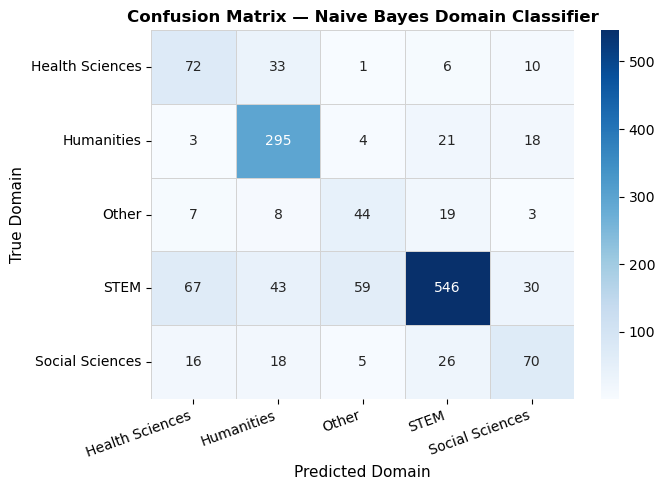

In [9]:
# Also had AI help here, I did not know how to make a confusion matrix

labels = sorted(df['domain'].unique())
cm = confusion_matrix(y_true, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels, yticklabels=labels, ax=ax,
    linewidths=0.5, linecolor='lightgray'
)
ax.set_xlabel('Predicted Domain', fontsize=11)
ax.set_ylabel('True Domain', fontsize=11)
ax.set_title('Confusion Matrix — Naive Bayes Domain Classifier', fontsize=12, fontweight='bold')
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()


### NOTE:
My discussion on these results is at the end of the notebook!

## 8a. Most Informative Features

This is the heart of what I was trying to do. `show_most_informative_features()` reports the words whose presence (or absence) most strongly shifts the probability toward a particular domain label.

The **likelihood ratio** shown (e.g. `STEM : Health Sciences = 18.0 : 1.0`) means a chunk containing that word is 18× more likely to be STEM than Health Sciences. High ratios signal tight, domain-specific vocabulary; low ratios signal shared language. Super cool.

Decided to print 40 features to get a rich picture of what distinguishes each domain.


In [10]:
print("TOP 40 MOST INFORMATIVE FEATURES")
print("-" * 35)
classifier.show_most_informative_features(40)


TOP 40 MOST INFORMATIVE FEATURES
-----------------------------------
Most Informative Features
            postdoctoral = True            Other : STEM   =    344.6 : 1.0
                    east = True           Humani : STEM   =    158.7 : 1.0
                     vet = True           Health : STEM   =    142.6 : 1.0
                 britain = True           Humani : STEM   =    112.1 : 1.0
                   music = True           Humani : STEM   =    102.0 : 1.0
                  middle = True           Humani : STEM   =     91.0 : 1.0
              contextual = True           Health : Humani =     78.7 : 1.0
               academics = True            Other : Health =     77.6 : 1.0
             literatures = True           Humani : STEM   =     76.9 : 1.0
             cooperative = True            Other : Health =     76.3 : 1.0
            intelligence = True           Social : Humani =     75.1 : 1.0
                scholars = True            Other : STEM   =     68.7 : 1.0
     

### 8b. Per-Domain Most Informative Features

I originally had stopped here, but I realized that it would be also interesting to get a cleaner picture of what vocabulary defines each domain; this part was very confusing to me, so once again, I am going to disclose that I had AI help in figuring out how to do it.

Essentially this looks at the top features that most strongly predict each class specifically, by examining the classifier's probability distributions directly.


In [11]:
from nltk.probability import DictionaryProbDist

print("Top predictive words per domain (based on feature log-probabilities):\n")

domain_top = {}
for domain in sorted(df['domain'].unique()):
    # For each vocab word, score P(word=True | domain) / P(word=True | other)
    scores = {}
    for word in vocab:
        # Build a feature dict with only this word set to True, all others False,
        # then ask the classifier how probable each domain is given that single word
        feat = {w: False for w in vocab}
        feat[word] = True
        probs = classifier.prob_classify(feat)

        # Record the probability assigned to the current domain
        # higher means this word is more characteristic of it
        scores[word] = probs.prob(domain)
    
    # Keep the 15 words that most strongly signal this domain
    top = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:15]
    domain_top[domain] = top

    
    print(f"  {domain}:")
    for word, score in top:
        print(f"    {word:<25} P={score:.4f}")
    print()


Top predictive words per domain (based on feature log-probabilities):



  Health Sciences:
    vet                       P=0.9999
    bme                       P=0.9999
    ent                       P=0.9999
    assistant                 P=0.9999
    physician                 P=0.9998
    determinants              P=0.9998
    nursing                   P=0.9998
    contextual                P=0.9998
    ans                       P=0.9998
    medical                   P=0.9996
    entomology                P=0.9996
    filter                    P=0.9995
    poster                    P=0.9994
    laboratory                P=0.9994
    disease                   P=0.9994



  Humanities:
    east                      P=0.2975
    early                     P=0.2365
    britain                   P=0.2360
    writing                   P=0.2219
    culture                   P=0.2217
    cultures                  P=0.2191
    ireland                   P=0.2142
    vertebrates               P=0.2038
    wild                      P=0.2038
    wfc                       P=0.2038
    asian                     P=0.1942
    french                    P=0.1935
    medieval                  P=0.1901
    archival                  P=0.1668
    north                     P=0.1619



  Other:
    scholars                  P=0.0013
    psa                       P=0.0012
    postdoctoral              P=0.0012
    composition               P=0.0005
    mcnair                    P=0.0004
    msp                       P=0.0004
    uhp                       P=0.0003
    honors                    P=0.0003
    academics                 P=0.0003
    cooperative               P=0.0003
    ross                      P=0.0002
    mgt                       P=0.0002
    extension                 P=0.0001
    marketing                 P=0.0001
    introduction              P=0.0001



  STEM:
    oceanography              P=0.0004
    processes                 P=0.0003
    soil                      P=0.0003
    edited                    P=0.0002
    fisheries                 P=0.0002
    nut                       P=0.0002
    abi                       P=0.0002
    aquaculture               P=0.0002
    abg                       P=0.0002
    writing                   P=0.0002
    nematology                P=0.0002
    organic                   P=0.0002
    properties                P=0.0002
    inorganic                 P=0.0002
    mechanical                P=0.0002



  Social Sciences:
    relations                 P=0.6626
    intelligence              P=0.6362
    sts                       P=0.6280
    artificial                P=0.6280
    disability                P=0.6013
    opportunity               P=0.5712
    oeoes                     P=0.5648
    esp                       P=0.4900
    iad                       P=0.4538
    geography                 P=0.4093
    cmn                       P=0.3895
    eastern                   P=0.3087
    enrichment                P=0.3018
    south                     P=0.3013
    anthropology              P=0.2995



### NOTE ON THE FEATURES:

**STEM appears as the baseline foil**. It loses ground whenever another domain's specific terminology appears.

**Humanities has the sharpest signal**, with exclusively literary and cultural terms (*literatures*, *literary*, *catalogue*, *medieval*, *latin*, *philosophy*) dominating the top ranks.

**Health Sciences** is defined by clinical vocabulary (*nursing*, *psychiatry*, *medical*) and institutional artifacts (*posters* likely refers to conference posters).

**"Other" surfaces meta-academic language** (*postdoctoral*, *scholars*, *academics*, *enrichment*); the vocabulary of support and research programs.

### NOTE ON THE PROBABILITY SCORES:

Each P value here represents P(domain | only this one word is present, all other vocabulary absent).

It is not a measure of how important a word is to the domain; it's more like how confidently the classifier assigns the domain when it sees only that single word and nothing else.

**Why Health Sciences scores near 1.0:** words like *vet*, *physician*, *nursing* are so exclusively tied to one domain that even in total isolation they almost fully determine the label.

**Why STEM scores so low:** STEM is a broad domain spanning biology, chemistry, agriculture, physics, and more. Its vocabulary is distributed. No single word is consistently diagnostic across the whole domain. Instead, the signal is spread across many sub-discipline-specific terms that individually carry weak signal when seen alone. So STEM is harder to pin down with a single word precisely because it contains more internal variation than the other domains.

## 9. Saving Results

Appending predicted domain labels back to the full corpus and save as CSV. This is more for my sake, because these labels could be usable as metadata in my original RAG pipeline (for example, to weight retrieval by domain relevance or to filter by subject area).


In [12]:
# Lastly I run the classifier on every chunk in the corpus, not just the test set.
df['predicted_domain'] = [
    classifier.classify(extract_features(row['combined_text'], vocab))
    for _, row in df.iterrows()
]
print("Generated predictions for full corpus.")

# Saving a trimmed version of the corpus with both rule-based and predicted domain labels
# — differences between the two columns highlight potentially mislabeled or interdisciplinary chunks
output_path = 'corpus_with_domains.csv'
df[['local_id', 'parent_id', 'libguide_title', 'chunk_title',
    'domain', 'predicted_domain', 'text']].to_csv(output_path, index=False)

print(f"Saved to {output_path}")
print(f"\nFinal domain distribution (predicted):")
print(df['predicted_domain'].value_counts().to_string())

Generated predictions for full corpus.
Saved to corpus_with_domains.csv

Final domain distribution (predicted):
predicted_domain
STEM               3088
Humanities         2022
Health Sciences     890
Social Sciences     762
Other               680


### 10. Discussion

With 72.1% accuracy across five classes (vs. 20% chance baseline), the classifier mostly demonstrates that academic domain membership is genuinely encoded in the language of library research guide chunks.

**STEM and Humanities** are the strongest performers (F1 0.80 each), reflecting the exclusivity of their vocabularies. STEM's main errors are confusions with Health Sciences and Other; makes sense given that agricultural, nutritional, and lab-science guides share clinical and procedural language with health-related guides.

**Health Sciences** is the weakest (F1 0.50). Its chunks bleed most into Humanities; perhaps guides like entomology or animal science were assigned to Health Sciences by the keyword rules, but their text doesn't read as clinical.

**Other** (F1 0.45); expected it is not a true academic discipline, so its institutional and meta-academic language overlaps with all four real domains depending on context.

**Social Sciences** struggles most at the boundary with STEM (26 misclassifications), likely because quantitative social science guides reference many of the same databases and methodological terms as STEM guides.

***The classifier performs best where discipline vocabulary is most exclusive, and struggles at domain boundaries. Domain membership and boundaries are genuinely encoded in how librarians describe and frame research resources.***